Number of stocks: 31


[*********************100%***********************]  31 of 31 completed


Dataset shape: (40548, 5)
Dataset shape: (40548, 6)

Target distribution:
target
1    0.561088
0    0.438912
Name: proportion, dtype: float64
Training set: 32438 rows
Test set: 8110 rows
Logistic Regression Accuracy: 0.5444

Classification Report:
XGBoost Accuracy: 0.5228

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.16      0.23      3695
           1       0.54      0.83      0.65      4415

    accuracy                           0.52      8110
   macro avg       0.49      0.49      0.44      8110
weighted avg       0.49      0.52      0.46      8110

        feature  importance
0      momentum    0.353086
2  price_factor    0.343853
1    volatility    0.303062


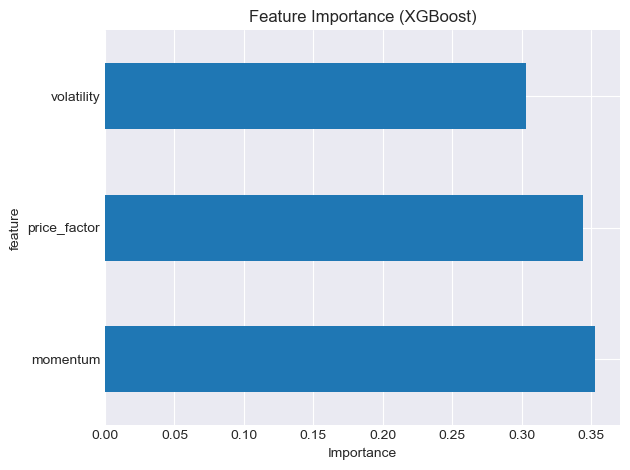

dataset_test rows: 8110, X_test rows: 8110
Date
2024-12-12   -0.003478
2024-12-13   -0.000685
2024-12-16   -0.001703
2024-12-17   -0.001388
2024-12-18   -0.020758
Name: strategy_return, dtype: float64
Strategy   -> Sharpe: 1.31, Max Drawdown: -14.13%, Final Value: 1.19
Benchmark  -> Sharpe: 1.05, Max Drawdown: -16.77%, Final Value: 1.18


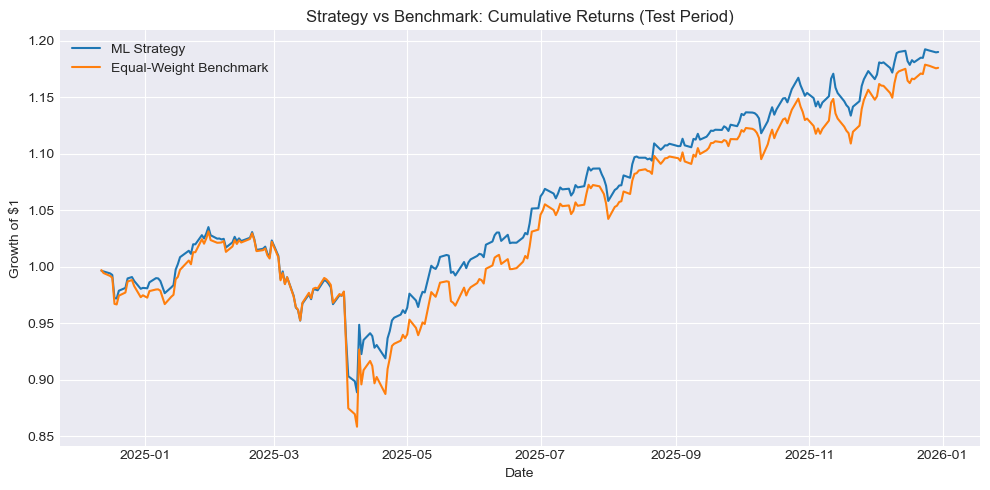

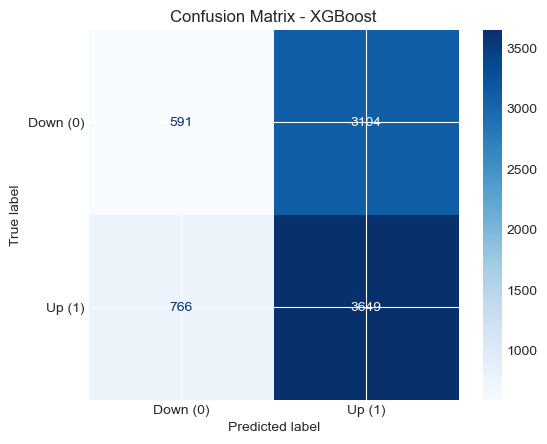

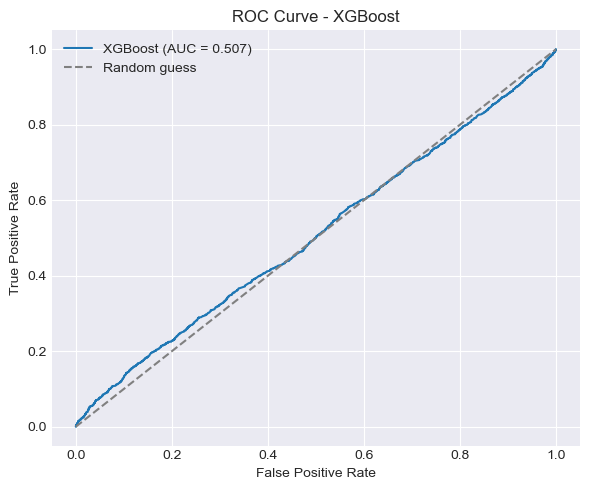

AUC Score: 0.5071


In [5]:
# ==========================================
# STEP 1: Setup
# ==========================================
!pip install yfinance xgboost --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# ==========================================
# STEP 2: Define stock universe
# ==========================================
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',      # Tech
    'JPM', 'BAC', 'GS', 'MS', 'C',                 # Financials
    'XOM', 'CVX', 'COP',                           # Energy
    'JNJ', 'PFE', 'UNH', 'MRK',                    # Healthcare
    'PG', 'KO', 'PEP', 'WMT',                      # Consumer staples
    'DIS', 'NKE', 'MCD', 'SBUX',                   # Consumer discretionary
    'CAT', 'BA', 'GE', 'HON',                      # Industrials
    'NEE', 'DUK'                                   # Utilities
]

print(f"Number of stocks: {len(tickers)}")

# ==========================================
# STEP 3: Download price data
# ==========================================
data = yf.download(tickers, start='2020-01-01', end='2025-12-31')['Close']
data.head()

# ==========================================
# STEP 4: Momentum factor
# ==========================================
momentum = data.pct_change(126)

# ==========================================
# STEP 5: Volatility factor
# ==========================================
daily_returns = data.pct_change()
volatility = daily_returns.rolling(21).std()

# ==========================================
# STEP 6: Price factor (distance from 200-day MA)
# ==========================================
moving_avg_200 = data.rolling(200).mean()
price_factor = (data - moving_avg_200) / moving_avg_200

# ==========================================
# STEP 7: Combine into one dataset
# ==========================================
rows = []

for ticker in tickers:
    df_ticker = pd.DataFrame({
        'momentum': momentum[ticker],
        'volatility': volatility[ticker],
        'price_factor': price_factor[ticker],
        'daily_return': daily_returns[ticker]
    })
    df_ticker['ticker'] = ticker
    rows.append(df_ticker)

dataset = pd.concat(rows)
dataset = dataset.dropna()

print(f"Dataset shape: {dataset.shape}")

# ==========================================
# STEP 8: Create target label
# ==========================================
forward_return = data.shift(-21) / data - 1
target = (forward_return > 0).astype(int)

# ==========================================
# STEP 9: Merge target into dataset
# ==========================================
rows = []

for ticker in tickers:
    df_ticker = pd.DataFrame({
        'momentum': momentum[ticker],
        'volatility': volatility[ticker],
        'price_factor': price_factor[ticker],
        'daily_return': daily_returns[ticker],
        'target': target[ticker]
    })
    df_ticker['ticker'] = ticker
    rows.append(df_ticker)

dataset = pd.concat(rows)
dataset = dataset.dropna()

print(f"Dataset shape: {dataset.shape}")
print(f"\nTarget distribution:\n{dataset['target'].value_counts(normalize=True)}")

# ==========================================
# STEP 10: Train/test split (chronological)
# ==========================================
dataset = dataset.sort_index()

features = ['momentum', 'volatility', 'price_factor']
X = dataset[features]
y = dataset['target']

split_index = int(len(dataset) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

# ==========================================
# STEP 11: Logistic Regression (baseline)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nClassification Report:")


# ==========================================
# STEP 12: XGBoost model
# ==========================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# ==========================================
# STEP 13: Feature importance
# ==========================================
importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

importance_df.plot(kind='barh', x='feature', y='importance', legend=False)
plt.xlabel('Importance')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 14: Backtest (FIXED - position-based alignment)
# ==========================================
dataset_test = dataset.iloc[split_index:].copy()

print(f"dataset_test rows: {len(dataset_test)}, X_test rows: {len(X_test)}")

backtest_df = dataset_test[['momentum', 'volatility', 'price_factor', 'daily_return', 'ticker']].copy()
backtest_df['prediction'] = y_pred_xgb

backtest_df['strategy_return'] = backtest_df['daily_return'] * backtest_df['prediction']

daily_portfolio_return = backtest_df.groupby(backtest_df.index)['strategy_return'].mean()
daily_benchmark_return = backtest_df.groupby(backtest_df.index)['daily_return'].mean()

print(daily_portfolio_return.head())

# ==========================================
# STEP 15: Cumulative returns, Sharpe, drawdown
# ==========================================
cumulative_strategy = (1 + daily_portfolio_return).cumprod()
cumulative_benchmark = (1 + daily_benchmark_return).cumprod()

def sharpe_ratio(returns, periods_per_year=252):
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

strategy_sharpe = sharpe_ratio(daily_portfolio_return)
benchmark_sharpe = sharpe_ratio(daily_benchmark_return)

def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

strategy_dd = max_drawdown(cumulative_strategy)
benchmark_dd = max_drawdown(cumulative_benchmark)

print(f"Strategy   -> Sharpe: {strategy_sharpe:.2f}, Max Drawdown: {strategy_dd:.2%}, Final Value: {cumulative_strategy.iloc[-1]:.2f}")
print(f"Benchmark  -> Sharpe: {benchmark_sharpe:.2f}, Max Drawdown: {benchmark_dd:.2%}, Final Value: {cumulative_benchmark.iloc[-1]:.2f}")

# ==========================================
# STEP 16: Plot cumulative returns
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(cumulative_strategy.index, cumulative_strategy.values, label='ML Strategy')
plt.plot(cumulative_benchmark.index, cumulative_benchmark.values, label='Equal-Weight Benchmark')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.title('Strategy vs Benchmark: Cumulative Returns (Test Period)')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# STEP 17: Confusion matrix and ROC curve
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
auc_score = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")